In [1]:
import numpy as np, local, cmblensplus.curvedsky as cs, healpy as hp, cmb
from matplotlib.pyplot import *

In [2]:
T, Q, U = hp.read_map('../data/lensing/S4BIRD/CMB_Lensed_Maps/CMB/cmb_sims_0002.fits',field=(0,1,2))

In [3]:
nside = hp.get_nside(T)
lmax = 4096
l = np.linspace(0,lmax,lmax+1)
lfac = l*(l+1)/2/np.pi

In [4]:
Talm = cs.utils.hp_map2alm(lmax,lmax,T)

In [5]:
Ealm, Balm = cs.utils.hp_map2alm_spin(lmax,lmax,2,Q,U)

In [6]:
cl = {}
cl['TT'] = cs.utils.alm2cl(Talm)
cl['EE'] = cs.utils.alm2cl(Ealm)
cl['BB'] = cs.utils.alm2cl(Balm)
cl['TE'] = cs.utils.alm2cl(Talm,Ealm)

In [7]:
CL = {}
L, CL['TT'], CL['EE'], CL['BB'], CL['TE'] = np.loadtxt('../data/lensing/S4BIRD/CAMB/BBSims_lensed_dls.dat',skiprows=1,unpack=True)

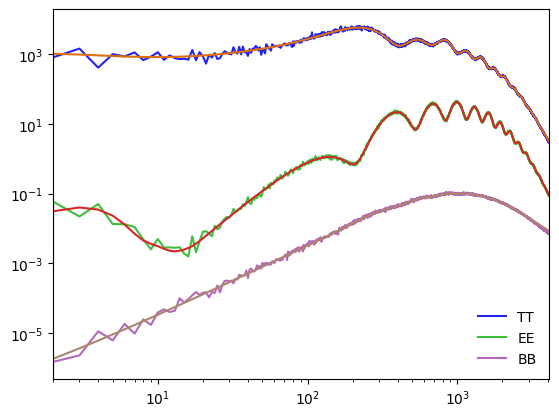

In [8]:
for c in ['TT','EE','BB']:
    xlim(2,lmax)
    loglog(l,cl[c]*lfac,label=c)
    loglog(L,CL[c])
legend()

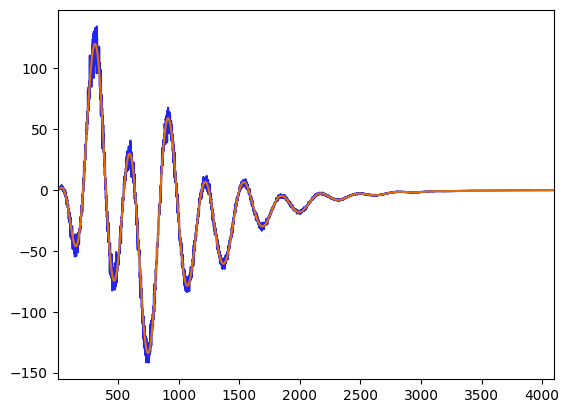

In [9]:
xlim(2,lmax)
plot(l,cl['TE']*lfac)
plot(L,CL['TE'])

In [10]:
palm = hp.read_alm('../data/lensing/S4BIRD/CMB_Lensed_Maps/MASS/phi_sims_0002.fits')

In [11]:
pmap = hp.sphtfunc.alm2map(palm,nside)

In [12]:
Palm = cs.utils.hp_map2alm(lmax,lmax,pmap)

In [13]:
PP = cs.utils.alm2cl(Palm)
TP = cs.utils.alm2cl(Talm,Palm)

In [14]:
L, __, __, __, pp, tp = np.loadtxt('../data/lensing/S4BIRD/CAMB/BBSims_scal_dls.dat',skiprows=1,unpack=True)

In [15]:
ucl = cmb.read_camb_cls('../data/lensing/S4BIRD/CAMB/BBSims_scal_dls.dat',output='array')[:,:lmax+1]

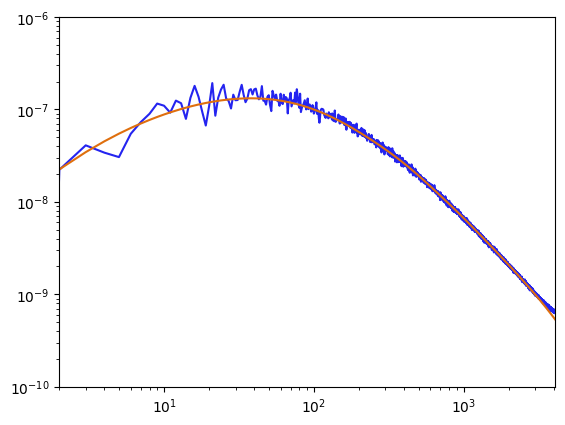

In [16]:
xlim(2,lmax)
ylim(1e-10,1e-6)
loglog(l,PP*(l*(l+1))**2/2/np.pi)
loglog(L[:lmax+1],pp[:lmax+1]/2.72e6**2/2/np.pi)

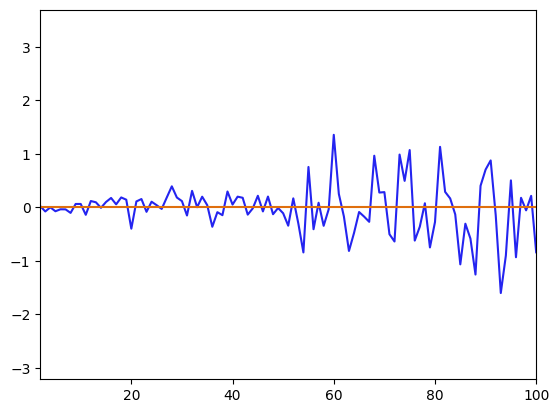

In [17]:
xlim(2,100)
plot(l,TP*(l*(l+1))**2)
plot(L[:lmax+1],tp[:lmax+1]/2.72e6**2/2/np.pi/L[:lmax+1])